<a href="https://colab.research.google.com/github/rgdeekshith/FIFA-World-Cup-EDA-Analysis/blob/main/FIFA_World_Cup_1930_2022_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots show inside the notebook
%matplotlib inline

# Set a basic plot style
sns.set(style="whitegrid")

In [5]:
# Replace this filename if your CSV has a different name
csv_path = "/content/fifa_worldcup_1930_2022.csv"

# Read the CSV into a pandas DataFrame
df = pd.read_csv(csv_path, encoding='latin1')

# Show the first 5 rows
df.head()

# Information of the CSV
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Key Id                     964 non-null    int64 
 1   Tournament Id              964 non-null    object
 2   tournament Name            964 non-null    object
 3   Match Id                   964 non-null    object
 4   Match Name                 964 non-null    object
 5   Stage Name                 964 non-null    object
 6   Group Name                 964 non-null    object
 7   Group Stage                964 non-null    int64 
 8   Knockout Stage             964 non-null    int64 
 9   Replayed                   964 non-null    int64 
 10  Replay                     964 non-null    int64 
 11  Match Date                 964 non-null    object
 12  Match Time                 964 non-null    object
 13  Stadium Id                 964 non-null    object
 14  Stadium Na

In [6]:
# Show all column names
df.columns.tolist()

# Basic shape: (rows, columns)
df.shape

(964, 37)

In [7]:
# 1. Convert Match Date to datetime
df["Match Date"] = pd.to_datetime(df["Match Date"], errors = "coerce")

# 2. Extract Year from Match Date
df["Year"] = df["Match Date"].dt.year

# 3. Create TotalGoals as sum of home and away goals
df["TotalGoals"] = df["Home Team Score"] + df["Away Team Score"]

# Look at the first 5 rows of the new columns
df[["Match Date", "Year", "Home Team Score", "Away Team Score", "TotalGoals"]].head()

,Match Date,Year,Home Team Score,Away Team Score,TotalGoals
0,1930-07-13,1930,4,1,5
1,1930-07-13,1930,3,0,3
2,1930-07-14,1930,2,1,3
3,1930-07-14,1930,3,1,4
4,1930-07-15,1930,1,0,1


In [8]:
# Overall descriptive stats for TotalGoals
df["TotalGoals"].describe()

# Average goals per match by Year
goals_by_year = df.groupby("Year")["TotalGoals"].mean()

goals_by_year.head()

# Find the year with the highest average goals
max_year = goals_by_year.idxmax()
max_avg_goals = goals_by_year.max()

# Find the year with the lowest average goals
min_year = goals_by_year.idxmin()
min_avg_goals = goals_by_year.min()

# Create a small DataFrame with just these two rows
extreme_years = pd.DataFrame({
    "Year": [min_year, max_year],
    "AverageGoals": [min_avg_goals, max_avg_goals]
})
print(extreme_years)

   Year  AverageGoals
0  1990      2.211538
1  1954      5.384615


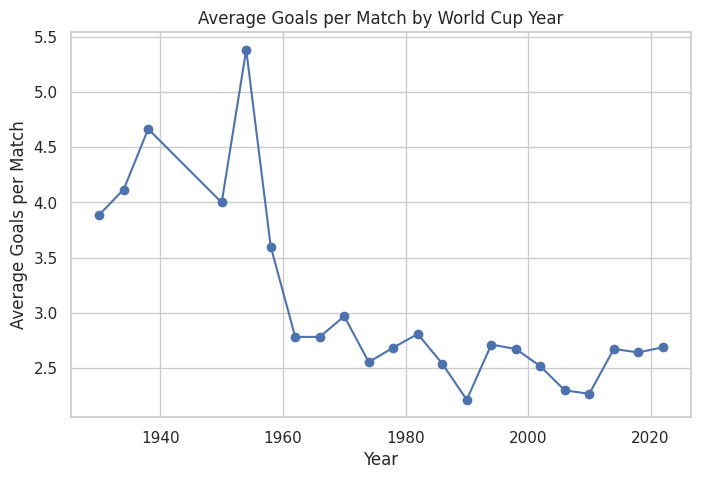

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(goals_by_year.index, goals_by_year.values, marker="o")
plt.title("Average Goals per Match by World Cup Year")
plt.xlabel("Year")
plt.ylabel("Average Goals per Match")
plt.grid(True)
plt.show()

In [10]:
# Goals scored when playing as the home team
home_goals_by_team = df.groupby("Home Team Name")["Home Team Score"].sum()

# Goals scored when playing as the away team
away_goals_by_team = df.groupby("Away Team Name")["Away Team Score"].sum()

# Align and add them to get total goals per team
total_goals_by_team = home_goals_by_team.add(away_goals_by_team, fill_value=0)

# Convert to a DataFrame and sort by total goals descending
team_goals_df = total_goals_by_team.sort_values(ascending=False).reset_index()
team_goals_df.columns = ["Team", "TotalGoals"]

# Show top 10 teams by total goals
team_goals_df.head(10)

,Team,TotalGoals
0,Brazil,237.0
1,Argentina,152.0
2,France,136.0
3,West Germany,131.0
4,Italy,128.0
5,Spain,108.0
6,England,104.0
7,Germany,101.0
8,Netherlands,96.0
9,Uruguay,89.0


In [11]:
# Wins as home team
home_wins = df.groupby("Home Team Name")["Home Team Win"].sum()

# Wins as away team
away_wins = df.groupby("Away Team Name")["Away Team Win"].sum()

# Total wins per team
total_wins_by_team = home_wins.add(away_wins, fill_value=0)

# Create DataFrame and sort
team_wins_df = total_wins_by_team.sort_values(ascending=False).reset_index()
team_wins_df.columns = ["Team", "TotalWins"]

# Show top 10 teams by total wins
team_wins_df.head(10)

,Team,TotalWins
0,Brazil,79.0
1,Argentina,53.0
2,Italy,46.0
3,France,41.0
4,West Germany,39.0
5,Germany,33.0
6,England,33.0
7,Spain,32.0
8,Netherlands,31.0
9,Uruguay,26.0


In [13]:
# Combine goals and wins into a single DataFrame
team_stats_df = pd.merge(
    team_goals_df,
    team_wins_df,
    on="Team",
    how="inner"
)

# Compute goals per win as a simple derived metric
team_stats_df["GoalsPerWin"] = team_stats_df["TotalGoals"] / team_stats_df["TotalWins"]

# Sort by total wins
team_stats_df_sorted = team_stats_df.sort_values("TotalWins", ascending=False)

team_stats_df_sorted.head(10)

,Team,TotalGoals,TotalWins,GoalsPerWin
0,Brazil,237.0,79.0,3.000000
1,Argentina,152.0,53.0,2.867925
4,Italy,128.0,46.0,2.782609
2,France,136.0,41.0,3.317073
3,West Germany,131.0,39.0,3.358974
6,England,104.0,33.0,3.151515
7,Germany,101.0,33.0,3.060606
5,Spain,108.0,32.0,3.375000
8,Netherlands,96.0,31.0,3.096774
9,Uruguay,89.0,26.0,3.423077


/tmp/ipykernel_16859/372413534.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


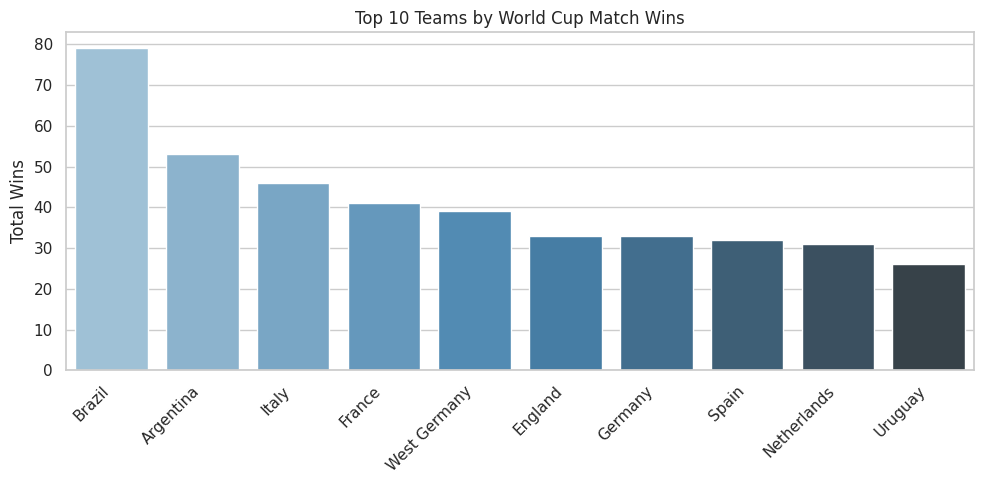

In [15]:
top10_wins = team_stats_df_sorted.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top10_wins,
    x="Team",
    y="TotalWins",
    palette="Blues_d"
)
plt.title("Top 10 Teams by World Cup Match Wins")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total Wins")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [26]:
# Matches as home team
home_matches = df.groupby("Home Team Name")["Match Id"].count()

# Matches as away team
away_matches = df.groupby("Away Team Name")["Match Id"].count()

# Total matches played per team
matches_played_by_team = home_matches.add(away_matches, fill_value=0)

# Convert to DataFrame
team_matches_df = matches_played_by_team.reset_index()
team_matches_df.columns = ["Team", "MatchesPlayed"]

team_matches_df.head(10)

,Team,MatchesPlayed
0,Algeria,13.0
1,Angola,3.0
2,Argentina,88.0
3,Australia,20.0
4,Austria,29.0
5,Belgium,51.0
6,Bolivia,6.0
7,Bosnia and Herzegovina,3.0
8,Brazil,114.0
9,Bulgaria,26.0


In [27]:
# Merge matches played into the existing team stats
team_stats_df = pd.merge(
    team_stats_df,
    team_matches_df,
    on="Team",
    how="inner"
)

# Compute Win Rate = TotalWins / MatchesPlayed
team_stats_df["WinRate"] = team_stats_df["TotalWins"] / team_stats_df["MatchesPlayed"]

# Sort by WinRate, but keep only teams with a reasonable number of matches (e.g., >= 10)
team_stats_with_enough_matches = team_stats_df[team_stats_df["MatchesPlayed"] >= 10]

top10_winrate = team_stats_with_enough_matches.sort_values(
    "WinRate",
    ascending=False
).head(10)

top10_winrate

,Team,TotalGoals,TotalWins,GoalsPerWin,MatchesPlayed_x,MatchesPlayed_y,MatchesPlayed,WinRate
0,Brazil,237.0,79.0,3.000000,114.0,114.0,114.0,0.692982
7,Germany,101.0,33.0,3.060606,50.0,50.0,50.0,0.660000
3,West Germany,131.0,39.0,3.358974,62.0,62.0,62.0,0.629032
1,Argentina,152.0,53.0,2.867925,88.0,88.0,88.0,0.602273
21,Croatia,43.0,17.0,2.529412,30.0,30.0,30.0,0.566667
8,Netherlands,96.0,31.0,3.096774,55.0,55.0,55.0,0.563636
2,France,136.0,41.0,3.317073,73.0,73.0,73.0,0.561644
4,Italy,128.0,46.0,2.782609,83.0,83.0,83.0,0.554217
14,Portugal,61.0,18.0,3.388889,35.0,35.0,35.0,0.514286
38,Turkey,20.0,5.0,4.000000,10.0,10.0,10.0,0.500000


/tmp/ipykernel_16859/3054015424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


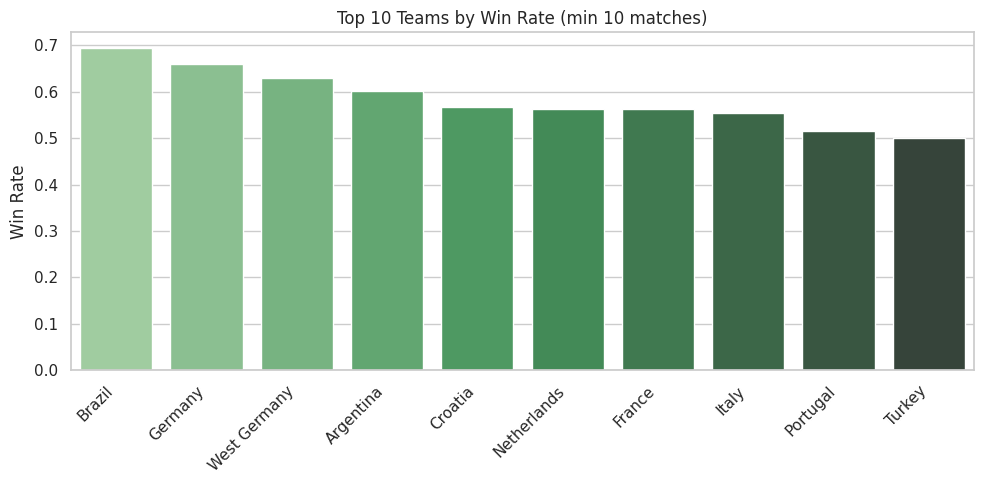

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top10_winrate,
    x="Team",
    y="WinRate",
    palette="Greens_d"
)
plt.title("Top 10 Teams by Win Rate (min 10 matches)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Win Rate")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [32]:
df[["Stage Name", "Group Stage", "Knockout Stage"]].head(10)

,Stage Name,Group Stage,Knockout Stage
0,group stage,1,0
1,group stage,1,0
2,group stage,1,0
3,group stage,1,0
4,group stage,1,0
5,group stage,1,0
6,group stage,1,0
7,group stage,1,0
8,group stage,1,0
9,group stage,1,0


In [34]:
# Average goals in group stage matches
group_stage_goals_mean = df.loc[df["Group Stage"] == 1, "TotalGoals"].mean()

# Average goals in knockout stage matches
knockout_stage_goals_mean = df.loc[df["Knockout Stage"] == 1, "TotalGoals"].mean()

group_stage_goals_mean, knockout_stage_goals_mean

(np.float64(2.6922005571030643), np.float64(3.1991869918699187))

In [36]:
stage_goals_summary = pd.DataFrame({
    "StageType": ["Group Stage", "Knockout Stage"],
    "AverageGoals": [group_stage_goals_mean, knockout_stage_goals_mean]
})

stage_goals_summary

,StageType,AverageGoals
0,Group Stage,2.692201
1,Knockout Stage,3.199187


/tmp/ipykernel_16859/7672778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


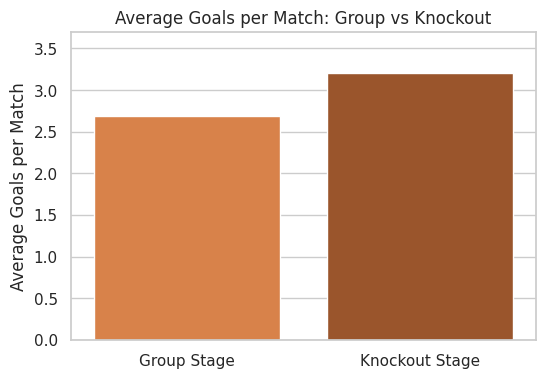

In [37]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=stage_goals_summary,
    x="StageType",
    y="AverageGoals",
    palette="Oranges_d"
)
plt.title("Average Goals per Match: Group vs Knockout")
plt.ylabel("Average Goals per Match")
plt.xlabel("")
plt.ylim(0, stage_goals_summary["AverageGoals"].max() + 0.5)
plt.show()

In [39]:
!pip install -U ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.4 MB/s eta 0:00:00


In [43]:
from ydata_profiling import ProfileReport

In [44]:
profile = ProfileReport(df, title="FIFA World Cup Data Profiling Report", explorative=True)

In [45]:
profile.to_file("FIFA_Analysis.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 39/39 [00:00<00:00, 50.07it/s]
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]